In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm
import cv2
import optuna
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Config
DATA_PATH = "Foodies_Challenge_Dataset"
TEST_PLATE_PATH = "plate_1.jpg"
IMG_SIZE = 224
EPOCHS = 15
NUM_CLASSES = 20

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Dataset
class FoodDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.images = []
        self.labels = []

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            for img_name in os.listdir(cls_dir):
                self.images.append(os.path.join(cls_dir, img_name))
                self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Model
class FoodClassifier(nn.Module):
    def __init__(self, num_classes):
        super(FoodClassifier, self).__init__()
        self.base_model = models.resnet18(pretrained=True)
        in_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

# Train and validation functions
def train_model(model, dataloader, criterion, optimizer, epoch):
    model.train()
    total_loss, correct, total = 0, 0, 0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch + 1}/{EPOCHS}")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': total_loss / (pbar.n + 1), 'acc': 100 * correct / total})
    return total_loss / len(dataloader), 100 * correct / total

def validate_model(model, dataloader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(dataloader), 100 * correct / total

# Load dataset
full_dataset = FoodDataset(DATA_PATH, transform=train_transform)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])
test_dataset.dataset.transform = val_transform

# Optuna objective
def objective(trial):
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-2)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model = FoodClassifier(NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    best_val_acc = 0.0
    for epoch in range(5):
        train_model(model, train_loader, criterion, optimizer, epoch)
        _, val_acc = validate_model(model, test_loader, criterion)
        scheduler.step()
        best_val_acc = max(best_val_acc, val_acc)
    return best_val_acc

# Run study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5)

print("Best Hyperparameters found:")
print(study.best_params)

# Use best params for final training
BATCH_SIZE = study.best_params['batch_size']
LEARNING_RATE = study.best_params['lr']
WEIGHT_DECAY = study.best_params['weight_decay']

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

model = FoodClassifier(NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

for epoch in range(EPOCHS):
    train_model(model, train_loader, criterion, optimizer, epoch)
    validate_model(model, test_loader, criterion)
    scheduler.step()

# Save final model
torch.save(model.state_dict(), "best_model.pth")


[I 2025-04-16 09:33:01,184] A new study created in memory with name: no-name-9fb79aa5-aaa8-47eb-8158-e1eeb624579d
C:\Users\madhu.SRM\AppData\Local\Temp\ipykernel_45004\2968260990.py:121: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
C:\Users\madhu.SRM\AppData\Local\Temp\ipykernel_45004\2968260990.py:123: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-2)
C:\Users\madhu.SRM\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 

Using device: cpu


Validating: 100%|██████████| 19/19 [00:26<00:00,  1.40s/it]
[I 2025-04-16 09:53:36,323] Trial 0 finished with value: 94.08825978351373 and parameters: {'lr': 3.749317065699971e-05, 'batch_size': 64, 'weight_decay': 3.422696963362998e-05}. Best is trial 0 with value: 94.08825978351373.
Validating: 100%|██████████| 38/38 [00:23<00:00,  1.61it/s]
[I 2025-04-16 10:13:59,928] Trial 1 finished with value: 70.60782681099084 and parameters: {'lr': 0.001279026161779287, 'batch_size': 32, 'weight_decay': 0.00274160868125354}. Best is trial 0 with value: 94.08825978351373.
Validating: 100%|██████████| 38/38 [00:17<00:00,  2.23it/s]
[I 2025-04-16 10:30:43,610] Trial 2 finished with value: 93.5886761032473 and parameters: {'lr': 0.0002408687238047168, 'batch_size': 32, 'weight_decay': 4.1599092603344866e-05}. Best is trial 0 with value: 94.08825978351373.
Validating: 100%|██████████| 76/76 [00:27<00:00,  2.75it/s]
[I 2025-04-16 10:50:45,492] Trial 3 finished with value: 63.197335553705244 and param

Best Hyperparameters found:
{'lr': 6.499437554393339e-05, 'batch_size': 16, 'weight_decay': 6.903968895496915e-06}


Validating: 100%|██████████| 76/76 [00:27<00:00,  2.74it/s]


Evaluating: 100%|██████████| 76/76 [00:27<00:00,  2.81it/s]


Classification Report:
              precision    recall  f1-score   support

  Aloo_matar       0.75      0.43      0.55         7
Besan_cheela       1.00      1.00      1.00        46
     Biryani       0.91      0.85      0.88        34
    Chapathi       0.95      0.96      0.96       106
Chole_bature       0.97      1.00      0.98        56
        Dahl       0.97      0.99      0.98       134
      Dhokla       0.99      0.97      0.98        78
        Dosa       0.98      0.94      0.96        48
 Gulab_jamun       1.00      1.00      1.00        20
        Idli       1.00      0.98      0.99        59
      Jalebi       0.99      1.00      0.99        94
Kadai_paneer       0.97      0.82      0.89        38
        Naan       0.96      0.96      0.96       119
  Paani_puri       0.88      0.97      0.92        30
      Pakoda       0.93      0.97      0.95        95
   Pav_bhaji       0.96      0.93      0.95        59
        Poha       0.90      1.00      0.95        46
    

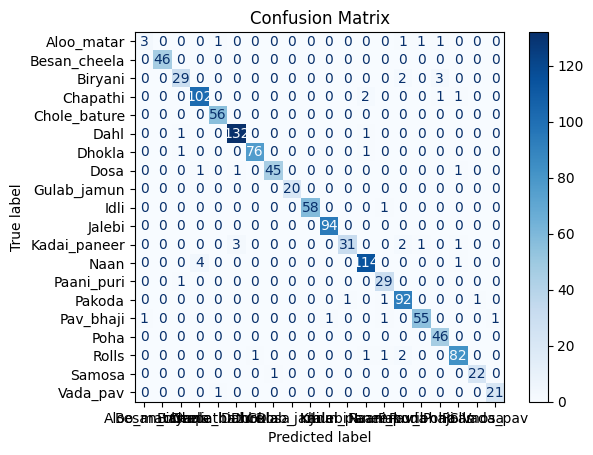

<Figure size 640x480 with 0 Axes>

In [ ]:
# Save final model with the best hyperparameters
torch.save(model.state_dict(), "best_model_with_best_params.pth")

# Evaluation Metrics: Classification Report and Confusion Matrix
model.eval()
y_true = []
y_pred = []

# Collect predictions and true labels for classification report and confusion matrix
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=full_dataset.classes))

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Optionally, save the confusion matrix plot
plt.savefig("confusion_matrix.png")


In [ ]:
# Load the image and apply the necessary transformations
def predict_image(image_path, model, transform):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)  # Add batch dimension and send to device

    # Make prediction
    model.eval()
    with torch.no_grad():
        output = model(image)
        _, predicted_class = torch.max(output, 1)

    return predicted_class.item()

# Path to the image
image_path = 'plate_1.jpg'

# Make prediction
predicted_class = predict_image(image_path, model, val_transform)

# Output the predicted class
print(f"Predicted Class ID: {predicted_class}")
print(f"Predicted Class Name: {full_dataset.classes[predicted_class]}")


Predicted Class ID: 3
Predicted Class Name: Chapathi


Detecting food items...


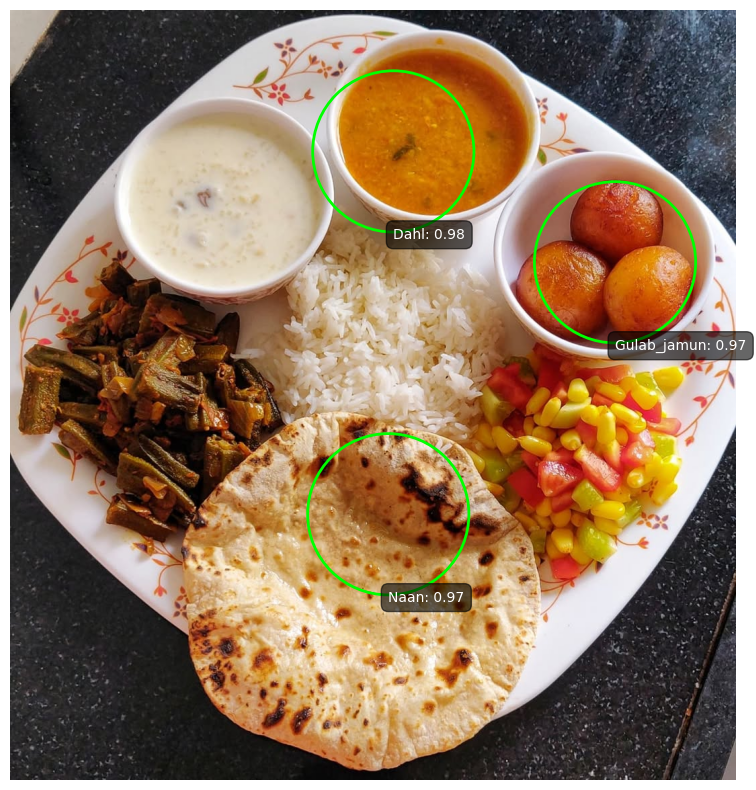


Detected Items:
- Dahl (Avg Confidence: 0.98)
- Gulab_jamun (Avg Confidence: 0.97)
- Naan (Avg Confidence: 0.97)


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

# Config
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224
MODEL_PATH = 'best_model.pth'
DATA_PATH = "Foodies_Challenge_Dataset"
TEST_PLATE_PATH = "plate_1.jpg"

# Dataset helper (for label names)
class FoodDatasetLabels:
    def __init__(self, root_dir):
        self.classes = sorted(os.listdir(root_dir))

# Model
class FoodClassifier(nn.Module):
    def __init__(self, num_classes):
        super(FoodClassifier, self).__init__()
        self.base_model = models.resnet18(pretrained=False)
        in_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

# Load class names
label_helper = FoodDatasetLabels(DATA_PATH)
class_names = label_helper.classes
NUM_CLASSES = len(class_names)

# Load model
model = FoodClassifier(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Sliding window prediction with custom shape (circle) adapted to the item size
def recognize_food_plate(model, image_path, class_names, confidence_thresh=0.9, distance_thresh=100):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    window_size = 300
    stride = 150
    detections = []

    for y in range(0, h - window_size + 1, stride):
        for x in range(0, w - window_size + 1, stride):
            crop = img[y:y+window_size, x:x+window_size]
            crop_pil = Image.fromarray(crop)
            crop_tensor = transform(crop_pil).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                output = model(crop_tensor)
                prob = torch.nn.functional.softmax(output, dim=1)
                max_prob, pred = torch.max(prob, 1)

                if max_prob.item() > confidence_thresh:
                    detections.append({
                        'box': (x, y, x+window_size, y+window_size),
                        'class': pred.item(),
                        'confidence': max_prob.item(),
                        'center': (x + window_size // 2, y + window_size // 2),  # Center of the crop
                        'width': window_size,  # Width of the item
                        'height': window_size  # Height of the item
                    })

    # Group detections by class and compute the average center for each group
    def group_by_class(detections):
        grouped = {}
        for det in detections:
            class_name = det['class']
            if class_name not in grouped:
                grouped[class_name] = []
            grouped[class_name].append(det)  # Keep the full detection information
        return grouped

    # Group detections by their class
    grouped_detections = group_by_class(detections)

    # Visualize with single circle per item at the center of grouped detections
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    ax = plt.gca()

    for class_id, detections_for_class in grouped_detections.items():
        # Calculate the average center for this class
        avg_center = np.mean([det['center'] for det in detections_for_class], axis=0)
        avg_width = np.mean([det['width'] for det in detections_for_class])
        avg_height = np.mean([det['height'] for det in detections_for_class])

        # Dynamically adjust the circle size based on the width and height
        # Larger items get a bigger circle, smaller items get a smaller circle
        radius = np.mean([avg_width, avg_height]) * 0.4  # Adjusting circle size (more scaling for larger items)

        # Draw circle with adapted radius
        circle = patches.Circle(avg_center, radius=radius, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(circle)

        # Add text with class name and average confidence
        avg_confidence = np.mean([det['confidence'] for det in detections_for_class])
        ax.text(avg_center[0], avg_center[1] + radius + 10,  # Place text closer to the circle
                f"{class_names[class_id]}: {avg_confidence:.2f}",
                color='white', bbox=dict(facecolor='black', alpha=0.6, boxstyle="round,pad=0.5"))

    plt.axis("off")
    plt.show()

    return grouped_detections

# Run inference
print("Detecting food items...")
detections = recognize_food_plate(model, TEST_PLATE_PATH, class_names)

print("\nDetected Items:")
for class_id, detections_for_class in detections.items():
    # Compute the average confidence for this class
    avg_confidence = np.mean([det['confidence'] for det in detections_for_class])
    print(f"- {class_names[class_id]} (Avg Confidence: {avg_confidence:.2f})")


Detecting food items...


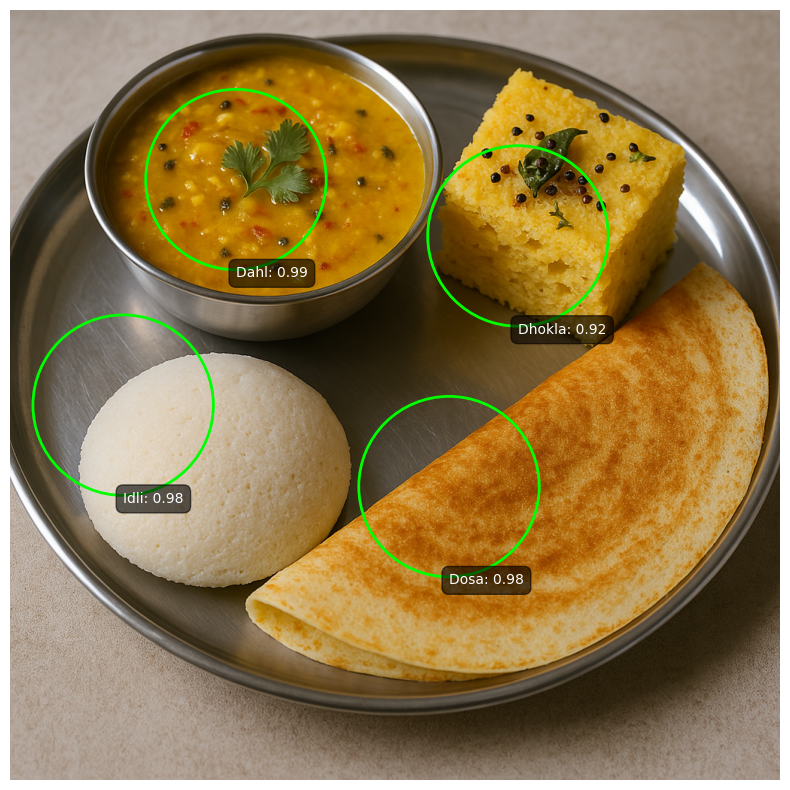


Detected Items:
- Dahl (Avg Confidence: 0.99)
- Dhokla (Avg Confidence: 0.92)
- Idli (Avg Confidence: 0.98)
- Dosa (Avg Confidence: 0.98)


In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

# Config
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224
MODEL_PATH = 'best_model.pth'
DATA_PATH = "Foodies_Challenge_Dataset"
TEST_PLATE_PATH = "plate_1.png"

# Dataset helper (for label names)
class FoodDatasetLabels:
    def __init__(self, root_dir):
        self.classes = sorted(os.listdir(root_dir))

# Model
class FoodClassifier(nn.Module):
    def __init__(self, num_classes):
        super(FoodClassifier, self).__init__()
        self.base_model = models.resnet18(pretrained=False)
        in_features = self.base_model.fc.in_features
        self.base_model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.base_model(x)

# Load class names
label_helper = FoodDatasetLabels(DATA_PATH)
class_names = label_helper.classes
NUM_CLASSES = len(class_names)

# Load model
model = FoodClassifier(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Sliding window prediction with custom shape (circle) adapted to the item size
def recognize_food_plate(model, image_path, class_names, confidence_thresh=0.9, distance_thresh=100):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    window_size = 300
    stride = 150
    detections = []

    for y in range(0, h - window_size + 1, stride):
        for x in range(0, w - window_size + 1, stride):
            crop = img[y:y+window_size, x:x+window_size]
            crop_pil = Image.fromarray(crop)
            crop_tensor = transform(crop_pil).unsqueeze(0).to(DEVICE)

            with torch.no_grad():
                output = model(crop_tensor)
                prob = torch.nn.functional.softmax(output, dim=1)
                max_prob, pred = torch.max(prob, 1)

                if max_prob.item() > confidence_thresh:
                    detections.append({
                        'box': (x, y, x+window_size, y+window_size),
                        'class': pred.item(),
                        'confidence': max_prob.item(),
                        'center': (x + window_size // 2, y + window_size // 2),  # Center of the crop
                        'width': window_size,  # Width of the item
                        'height': window_size  # Height of the item
                    })

    # Group detections by class and compute the average center for each group
    def group_by_class(detections):
        grouped = {}
        for det in detections:
            class_name = det['class']
            if class_name not in grouped:
                grouped[class_name] = []
            grouped[class_name].append(det)  # Keep the full detection information
        return grouped

    # Group detections by their class
    grouped_detections = group_by_class(detections)

    # Visualize with single circle per item at the center of grouped detections
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    ax = plt.gca()

    for class_id, detections_for_class in grouped_detections.items():
        # Calculate the average center for this class
        avg_center = np.mean([det['center'] for det in detections_for_class], axis=0)
        avg_width = np.mean([det['width'] for det in detections_for_class])
        avg_height = np.mean([det['height'] for det in detections_for_class])

        # Dynamically adjust the circle size based on the width and height
        # Larger items get a bigger circle, smaller items get a smaller circle
        radius = np.mean([avg_width, avg_height]) * 0.4  # Adjusting circle size (more scaling for larger items)

        # Draw circle with adapted radius
        circle = patches.Circle(avg_center, radius=radius, linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(circle)

        # Add text with class name and average confidence
        avg_confidence = np.mean([det['confidence'] for det in detections_for_class])
        ax.text(avg_center[0], avg_center[1] + radius + 10,  # Place text closer to the circle
                f"{class_names[class_id]}: {avg_confidence:.2f}",
                color='white', bbox=dict(facecolor='black', alpha=0.6, boxstyle="round,pad=0.5"))

    plt.axis("off")
    plt.show()

    return grouped_detections

# Run inference
print("Detecting food items...")
detections = recognize_food_plate(model, TEST_PLATE_PATH, class_names)

print("\nDetected Items:")
for class_id, detections_for_class in detections.items():
    # Compute the average confidence for this class
    avg_confidence = np.mean([det['confidence'] for det in detections_for_class])
    print(f"- {class_names[class_id]} (Avg Confidence: {avg_confidence:.2f})")
